<a href="https://colab.research.google.com/github/KellyTBG/Inga-taxonomy-andes/blob/main/notebooks/Inga_taxonomy_andes_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Determining the best morphological characters for taxonomic identification of Inga species in the Colombian Andes using correlation, entropy and a discriminant index**

By Kelly T. Bocanegra-González - 2025

PhytoKeys 267: 345–360 (2025)
DOI: (https://doi.org/10.3897/phytokeys.267.172490)

Interactive key: [https://padme.rbge.org.uk/keys/welcome/inga]

Here we would use Pearson's & Spearman correlation, Shannon entropy and discrimnat linear analysis to prioritize morphological characters in *Inga* from the Colombian Andes. Subsequently, we create an interactive identification key.


# **1. Upload data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Leer archivo original
df = pd.read_excel("/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Inga_interactive-key_padme.xlsx", engine='openpyxl')

# **2. Cleaning data**

We excluded non-categorical columns and applied average frequency encoding to the remaining categorical characters with multiple states. Each state was weighted according to its frequency across the dataset, and the encoded values replaced the original categorical columns.

*Average frequency encoding assigns values based on how often each state appears across the dataset. For cells containing multiple states, the method calculates the mean frequency of all states present in that cell.

In [ ]:
import numpy as np

df = df.copy()

# Exclude non-categorical columns from encoding
exclude_cols = ['Species', 'Altitud_Pennington_1997', 'Max_Altitude_Col', 'Tree height', 'DAP', 'Altitude_range']
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in exclude_cols]

# Average frequency encoding for categorical characters with multiple states
def frequency_encoding_multistate(series):
    flat = series.dropna().str.split(',').explode().str.strip()
    freq = flat.value_counts(normalize=True).to_dict()

    def encode_cell(cell):
        if pd.isna(cell):
            return np.nan
        parts = [p.strip() for p in str(cell).split(',')]
        values = [freq.get(p, 0) for p in parts]
        return np.mean(values) if values else np.nan

    return series.map(encode_cell)

# Replace original categorical columns with encoded values
for col in categorical_cols:
    df[col] = frequency_encoding_multistate(df[col])

# save
df.to_csv("/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/character_standarization.csv", index=False)

- We automatically identify numerical and categorical columns in the dataset based on their data types. Then, we print the names and data types of the categorical columns, as well as the names of the numerical columns.

In [ ]:
# Automatically identify numerical and categorical columns
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(exclude=['number']).columns.tolist()

# Print categorical and numerical columns
# Print data types of categorical columns
print("\nColumnas categóricas:")
print(categorical_columns)

print("\nColumnas numéricas:")
print(numerical_columns)

print(df[categorical_columns].dtypes)


Columnas categóricas:
['Species']

Columnas numéricas:
['Altitud_Pennington_1997', 'Max_Altitude_Col', 'Tree height', 'DAP', 'Twig shape', 'Twig feature', 'Stipule shape', 'Stipule indument', 'Stipule persistence', 'Stipule length_min (mm)', 'Stipule length_max (mm)', 'Petiole shape', 'Petiole length_min (cm)', 'Petiole length_max (cm)', 'Type of indumentum on petiole', 'Indumentum density on petiole', 'Rachis length_min (cm)', 'Rachis length_max (cm)', 'Rachis shape', 'Rachis apical appendix', 'Wing shape', 'Wing length_min (mm)', 'Wing length_max (mm)', 'Interfoliar nectaries attachment', 'Interfoliar nectaries shape', 'Interfoliar nectaries special features', 'Interfoliar nectaries diameter_min (mm)', 'Interfoliar nectaries diameter_max (mm)', 'Nectaries length (mm)', 'Leaflets pairs_min', 'Leaflets pairs_max', 'Terminal leaflet_Length_min (cm)', 'Terminal leaflet_Length_max (cm)', 'Terminal leaflet_Width_min (cm)', 'Terminal leaflet_Width_max (cm)', 'Terminal leaflet shape', 'Term

- We calculate the range (max - min) for selected character pairs and create new columns to store these values. Once the range is computed, the original min and max columns are removed from the dataframe to simplify the dataset.

In [ ]:
# Manually define min-max character pairs
range_pairs = [
    ("Stipule length_min (mm)", "Stipule length_max (mm)", "Stipule length_range"),
    ("Petiole length_min (cm)", "Petiole length_max (cm)", "Petiole length_range"),
    ("Rachis length_min (cm)", "Rachis length_max (cm)", "Rachis length_range"),
    ("Wing length_min (mm)", "Wing length_max (mm)", "Wing length_range"),
    ("Interfoliar nectaries diameter_min (mm)", "Interfoliar nectaries diameter_max (mm)", "Interfoliar nectaries diameter_range"),
    ("Leaflets pairs_min", "Leaflets pairs_max", "Leaflets pairs_range"),
    ("Terminal leaflet_Length_min (cm)", "Terminal leaflet_Length_max (cm)", "Terminal leaflet_Length_range"),
    ("Terminal leaflet_Width_min (cm)", "Terminal leaflet_Width_max (cm)", "Terminal leaflet_Width_range"),
    ("Basal leaflet_Length_min (cm)", "Basal leaflet_Length_max (cm)", "Basal leaflet_Length_range"),
    ("Basal leaflet_Width_min (cm)", "Basal leaflet_Width_max (cm)", "Basal leaflet_Width_range"),
    ("Secondary vein pairs in a leaflet_min", "Secondary vein pairs in a leaflet_max", "Secondary vein pairs in a leaflet_range"),
    ("Calyx length_min (mm)", "Calyx length_max (mm)", "Calyx length_range"),
    ("Corolla length_min (mm)", "Corolla length_max (mm)", "Corolla length_range"),
    ("Fruit_length_min (cm)", "Fruit_length_max (cm)", "Fruit_length_range"),
    ("Fruit_width_min (cm)", "Fruit_width_max (cm)", "Fruit_width_range"),
    ("Fruit_thickness_min (cm)", "Fruit_thickness_max (cm)", "Fruit_thickness_range"),
]

# Create range columns and remove original min/max columns
for min_col, max_col, range_col in range_pairs:
    if min_col in df.columns and max_col in df.columns:
        df[range_col] = pd.to_numeric(df[max_col], errors='coerce') - pd.to_numeric(df[min_col], errors='coerce')
        df.drop(columns=[min_col, max_col], inplace=True)
        print(f"✅ {range_col} creada correctamente.")
    else:
        print(f"⚠️ Columnas faltantes: {min_col} o {max_col}")


✅ Stipule length_range creada correctamente.
✅ Petiole length_range creada correctamente.
✅ Rachis length_range creada correctamente.
✅ Wing length_range creada correctamente.
✅ Interfoliar nectaries diameter_range creada correctamente.
✅ Leaflets pairs_range creada correctamente.
✅ Terminal leaflet_Length_range creada correctamente.
✅ Terminal leaflet_Width_range creada correctamente.
✅ Basal leaflet_Length_range creada correctamente.
✅ Basal leaflet_Width_range creada correctamente.
✅ Secondary vein pairs in a leaflet_range creada correctamente.
✅ Calyx length_range creada correctamente.
✅ Corolla length_range creada correctamente.
✅ Fruit_length_range creada correctamente.
✅ Fruit_width_range creada correctamente.
✅ Fruit_thickness_range creada correctamente.


In [ ]:
print(df.columns.tolist())


['Species', 'Altitud_Pennington_1997', 'Max_Altitude_Col', 'Tree height', 'DAP', 'Twig shape', 'Twig feature', 'Stipule shape', 'Stipule indument', 'Stipule persistence', 'Petiole shape', 'Type of indumentum on petiole', 'Indumentum density on petiole', 'Rachis shape', 'Rachis apical appendix', 'Wing shape', 'Interfoliar nectaries attachment', 'Interfoliar nectaries shape', 'Interfoliar nectaries special features', 'Nectaries length (mm)', 'Terminal leaflet shape', 'Terminal leaflet apex shape', 'Terminal leaflet base shape', 'Basal leaflet shape', 'Basal leaflet apex shape', 'Basal leaflet base shape', 'Indumentum type on lamina (abaxial)', 'Indumentum density on lamina (abaxial)', 'Indumentum type on lamina (adaxial)', 'Indumentum density on lamina (adaxial)', 'Venation pattern in leaflets', 'Inflorescence position', 'Inflorescence type', 'Calyx shape', 'Calyx indument', 'Fruit curvature', 'Fruit cross-sectional shape', 'Fruit cross-sectional frame', 'Stipule length_range', 'Petiole 

- Transforming continuous morphological ranges into discrete bins to standardize character states for the analysis.
Then, rename each character with a cleaner, final label and remove the original range columns to keep the dataset tidy.

In [ ]:
# Manual cut-off dictionary for each character based on the dataset
binning_rules = {
    "Stipule length_range": [0, 5, 15, 25, 40],
    "Petiole length_range": [0, 2, 5, 10, 20],
    "Rachis length_range": [0, 5, 15, 25, 35],
    "Wing length_range": [0, 5, 10, 20, 30],
    "Interfoliar nectaries diameter_range": [0, 2, 5, 7, 12],
    "Leaflets pairs_range": [0, 2, 4, 6, 11],
    "Terminal leaflet_Length_range": [0, 10, 20, 30, 45],
    "Terminal leaflet_Width_range": [0, 5, 10, 15, 25],
    "Basal leaflet_Length_range": [0, 5, 10, 15, 25],
    "Basal leaflet_Width_range": [0, 3, 6, 9, 12],
    "Secondary vein pairs in a leaflet_range": [0, 6, 10, 15, 21],
    "Calyx length_range": [0, 10, 20, 30, 40],
    "Corolla length_range": [0, 15, 30, 50, 70],
    "Fruit_length_range": [0, 20, 40, 70, 110],
    "Fruit_width_range": [0, 2.5, 5, 7.5, 12],
    "Fruit_thickness_range": [0, 1, 2, 3, 5]
}

# Final shorter names for analysis
final_names = {
    "Stipule length_range": "Stipule length (mm)",
    "Petiole length_range": "Petiole length (cm)",
    "Rachis length_range": "Rachis length (cm)",
    "Wing length_range": "Wing length (mm)",
    "Interfoliar nectaries diameter_range": "Interfoliar nectary diameter (mm)",
    "Leaflets pairs_range": "Number of leaflet pairs",
    "Terminal leaflet_Length_range": "Terminal leaflet length (cm)",
    "Terminal leaflet_Width_range": "Terminal leaflet width (cm)",
    "Basal leaflet_Length_range": "Basal leaflet length (cm)",
    "Basal leaflet_Width_range": "Basal leaflet width (cm)",
    "Secondary vein pairs in a leaflet_range": "Secondary vein pairs in a leaflet",
    "Calyx length_range": "Calyx length (mm)",
    "Corolla length_range": "Corolla length (mm)",
    "Fruit_length_range": "Fruit length (cm)",
    "Fruit_width_range": "Fruit width (cm)",
    "Fruit_thickness_range": "Fruit thickness (cm)"
}

# Convert continuous range values into discrete classes using the range mean
def bin_range_value_continuous(val, bins):
    try:
        return pd.cut([val], bins=bins, labels=False, include_lowest=True)[0] + 1
    except:
        return np.nan

for col, bins in binning_rules.items():
    if col in df.columns:
        clean_name = final_names[col]
        df[clean_name] = df[col].apply(lambda r: bin_range_value_continuous(r, bins))

# Remove original *_range columns if they are no longer needed
df = df.drop(columns=[col for col in binning_rules.keys() if col in df.columns])

- We are removing specific columns from the dataset to focus only on relevant variables. Then, we check if any remaining columns are non-numeric, which could interfere with subsequent numerical analyses like correlation.

In [ ]:
# Exclude columns by name
excluir = ['Species', 'Altitud_Pennington_1997', 'Max_Altitude_Col', 'Tree height', 'DAP']  # Nombres de las columnas a excluir
df = df.drop(columns=excluir)

# Check for non-numerical columns
non_numeric = df.select_dtypes(exclude=['number'])
print("Columnas no numéricas en df_corr:", non_numeric.columns.tolist())

Columnas no numéricas en df_corr: []


# **3. Analyses**

## **3.1. Normalise**

We are normalizing all numeric columns in df_corr to a 0–1 scale using MinMaxScaler. MinMaxScaler transforms each value using the formula (x - min) / (max - min), preserving the original distribution but rescaling the range. The normalized dataset is then saved as a CSV file.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler to all numeric columns in df_corr
scaler = MinMaxScaler()
df[df.columns] = scaler.fit_transform(df)

# (Opcional) save dataframe
df.to_csv("/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/character_standarization_normalized.csv", index=False)

## **3.2 Spearman**

We convert all character values to numeric and identify constant columns, which lack variation and are not useful for correlation analysis. Then, we compute the Spearman correlation matrix to assess monotonic relationships between characters with sufficient data.

In [ ]:
import pandas as pd
import scipy.stats as stats

# Convert all dataframe values to numeric format
df = df.apply(pd.to_numeric, errors='coerce')

# Identify columns with no variation
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Columnas constantes (sin variación):", constant_columns)

# Remove constant columns before correlation analysis
df = df.drop(columns=constant_columns)

# Calculate Spearman correlation matrix
corr_spearman = df.corr(method='spearman', min_periods=3)

# Sort rows and columns alphabetically after correlation calculation
order = sorted(corr_spearman.columns, key=str.casefold)  # orden alfabético, ignore case
corr_spearman = corr_spearman.reindex(index=order, columns=order)

# Print correlation matrix
print(corr_spearman)

Columnas constantes (sin variación): []
                                        Basal leaflet apex shape  \
Basal leaflet apex shape                                1.000000   
Basal leaflet base shape                               -0.008241   
Basal leaflet length (cm)                               0.088074   
Basal leaflet shape                                    -0.029830   
Basal leaflet width (cm)                                0.069929   
Calyx indument                                         -0.053576   
Calyx length (mm)                                      -0.063387   
Calyx shape                                            -0.002724   
Corolla length (mm)                                    -0.159724   
Fruit cross-sectional frame                             0.115936   
Fruit cross-sectional shape                             0.124595   
Fruit curvature                                         0.282505   
Fruit length (cm)                                       0.022664   
Fruit th

In [ ]:
print("Número de caracteres:", df.shape[1])

Número de caracteres: 49


We generate a heatmap to visualize Spearman correlations between characters. Missing correlation values (NaN) which occur when there are insufficient data to compute a valid relationship are temporarily replaced with zeros to ensure the heatmap renders correctly. These zeros do not imply a lack of correlation but are used only for visualization purposes; the actual NaN values should be respected in any analytical interpretation.

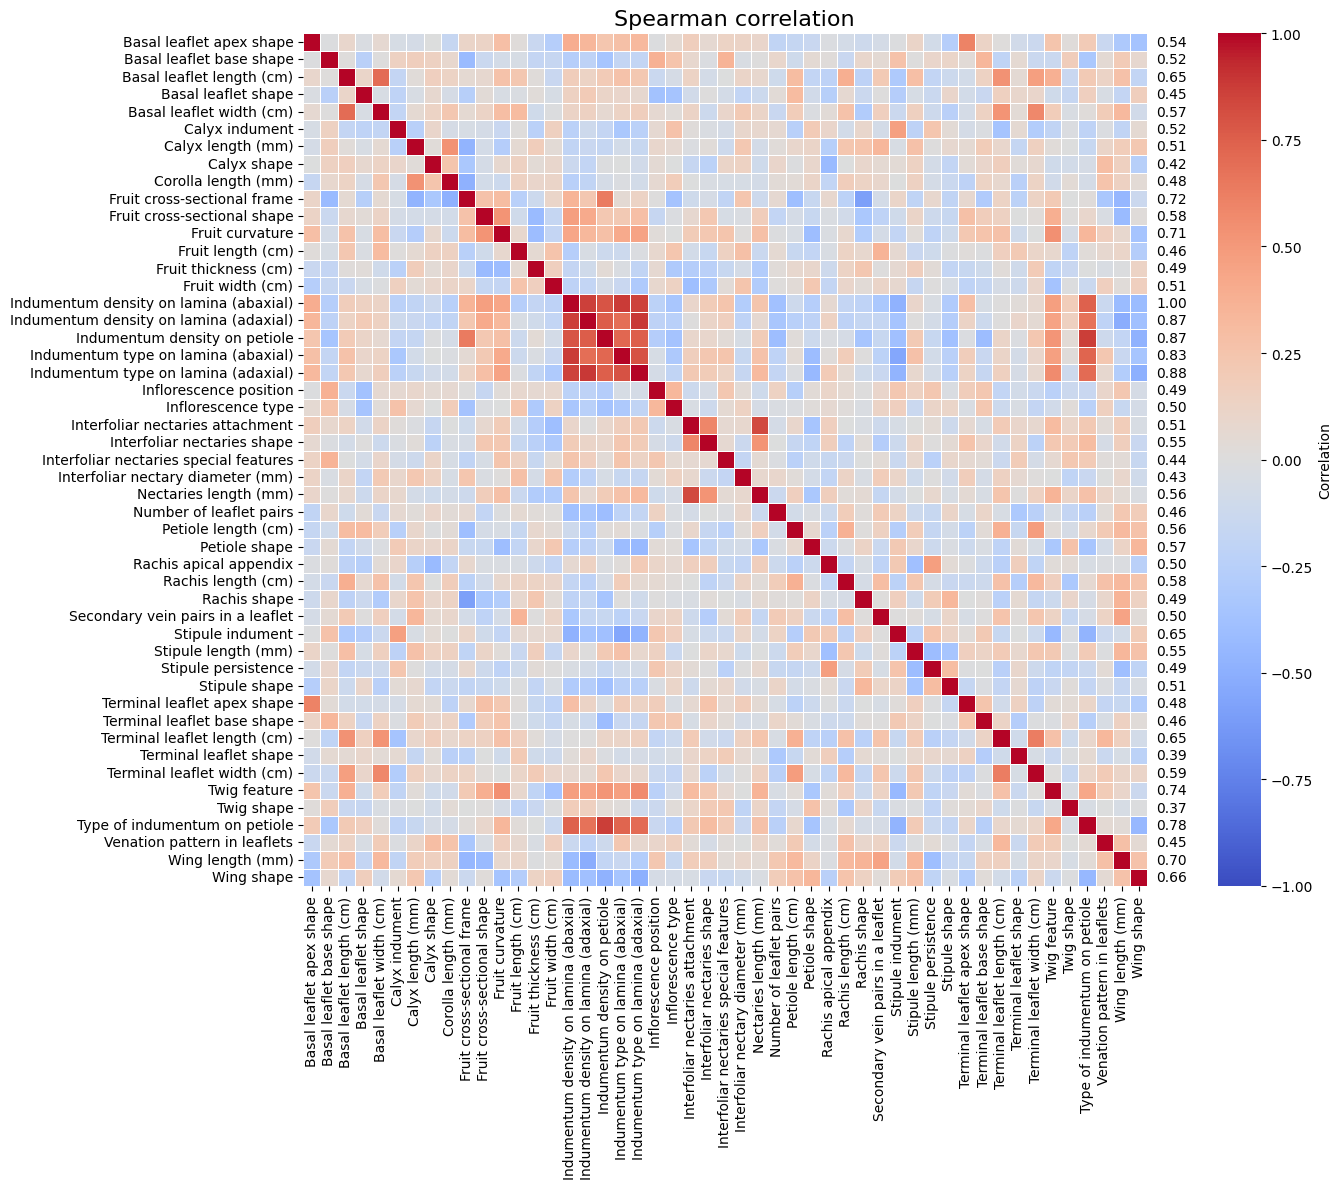

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Replace NaN values with 0 for visualization only
corr_spearman = corr_spearman.fillna(0)

# Create figure
plt.figure(figsize=(14, 12))

# Generate Spearman correlation heatmap
sns.heatmap(corr_spearman,
            # Uncomment the next line to use mask (Option 2)
            # mask=mask,
            annot=False,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})

# Format axis labels
plt.yticks(rotation=0, fontsize=10)
plt.xticks(ticks=np.arange(corr_spearman.shape[1]) + 0.5,
           labels=corr_spearman.columns,
           rotation=90, fontsize=10)

# Calculate row-wise sums of absolute correlations
row_sums = corr_spearman.abs().sum(axis=1)
normalized_sums = np.clip(row_sums / row_sums.max(), 0, 1)

# Add normalized correlation sums beside the heatmap
for i, sum_val in enumerate(normalized_sums):
    plt.text(corr_spearman.shape[1] + 0.5, i + 0.5, f'{sum_val:.2f}',
             va='center', ha='left', fontsize=10)

# Adjust plot limits and title
plt.xlim(0, corr_spearman.shape[1] + 1)
plt.title("Spearman correlation", fontsize=16)
plt.tight_layout()

# Save figure
plt.savefig('/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/spearman_heatmap_paper.png', dpi=600, bbox_inches='tight')

# Display plot
plt.show()

## **3.4 Entropy**

We compute the Shannon entropy for each character in df to measure how informative or variable it is. Then, we sort and visualize these entropy values in a horizontal barplot.  Characters with higher entropy exhibit more diversity in their values and are more likely to separate species effectively. The results are visualized in a barplot for easy comparison.

                                  Caracter   Entropy
0                               Twig shape  2.572489
1                             Twig feature  1.507509
2                            Stipule shape  3.877338
3                         Stipule indument  0.963193
4                      Stipule persistence  1.348111
5                            Petiole shape  3.678010
6            Type of indumentum on petiole  3.667325
7            Indumentum density on petiole  2.523149
8                             Rachis shape  2.702553
9                   Rachis apical appendix  1.294626
10                              Wing shape  1.691933
11        Interfoliar nectaries attachment  1.092475
12             Interfoliar nectaries shape  2.775170
13  Interfoliar nectaries special features  0.947382
14                   Nectaries length (mm)  1.068916
15                  Terminal leaflet shape  2.258831
16             Terminal leaflet apex shape  3.083009
17             Terminal leaflet base shape  3.

/tmp/ipython-input-626440906.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


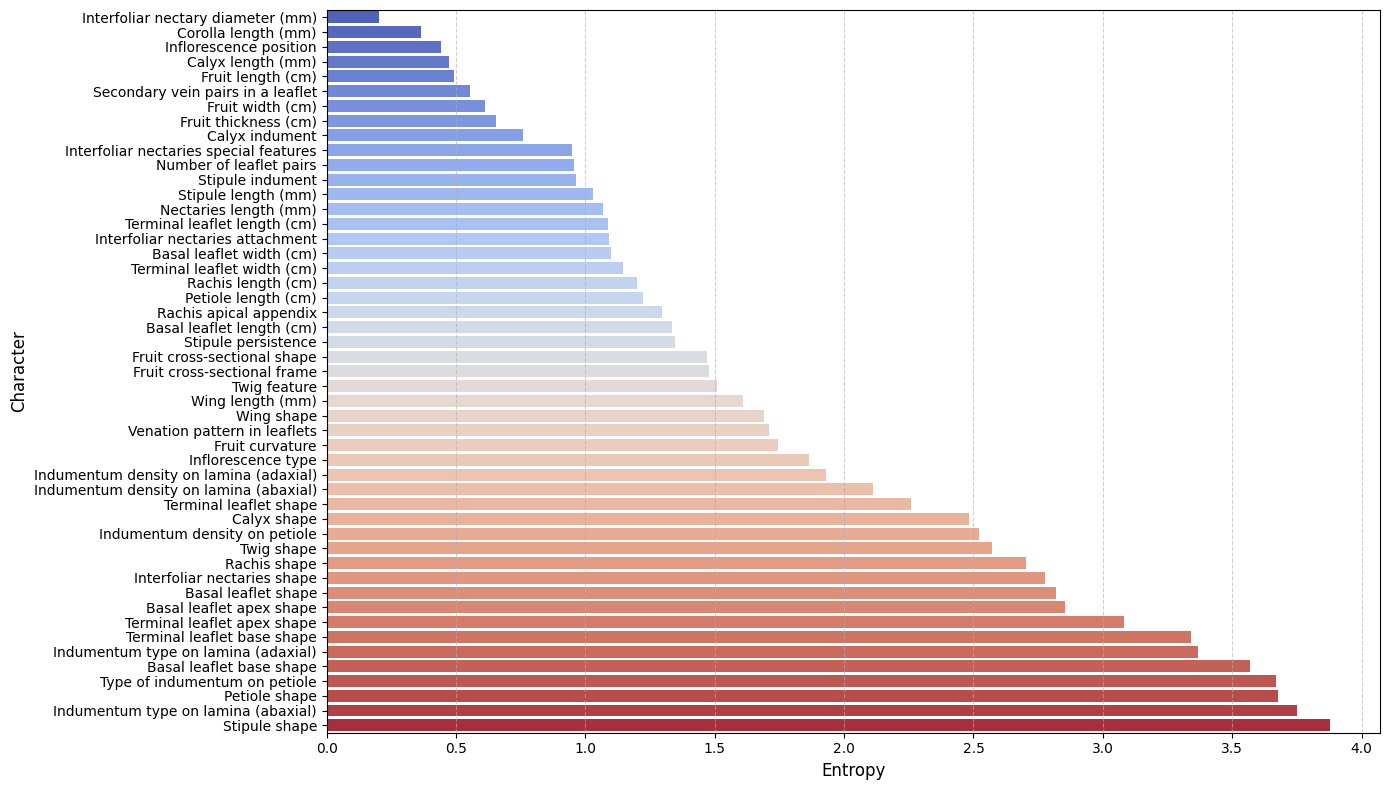

In [ ]:
import numpy as np

# Calculate entropy for a single column
def calcular_entropia(columna):
    # Calcular la frecuencia de cada valor único
    frecuencias = columna.value_counts(normalize=True)
    # Aplicar la fórmula de entropía
    entropia = -np.sum(frecuencias * np.log2(frecuencias))
    return entropia

# Calculate entropy values for all dataframe columns
entropias = df.apply(calcular_entropia)

# Convert entropy results into a dataframe
entropias = entropias.to_frame(name='Entropy')  # Nombre de la columna
entropias = entropias.reset_index().rename(columns={'index': 'Caracter'})  # Renombrar la columna índice

# Print entropy values
print(entropias)

# Sort characters by entropy values
entropias_sorted = entropias.sort_values(by='Entropy')

# Create entropy barplot
plt.figure(figsize=(14, 8))
sns.barplot(
    x='Entropy',  # Eje X: Entropy
    y='Caracter',  # Eje Y: Characters
    data=entropias_sorted,  # Data
    palette='coolwarm'  # colours
)

# Add axis labels
plt.xlabel("Entropy", fontsize=12)
plt.ylabel("Character", fontsize=12)

# Improve plot visualization
plt.grid(axis='x', linestyle='--', alpha=0.6)  # Añadir líneas de cuadrícula en el eje X
plt.tight_layout()  # Ajustar el layout para evitar superposiciones

# Save figure
plt.savefig('/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/entropy_paper.png', dpi=600, bbox_inches='tight')

plt.show()

**3.5 Discrimination Index (Discriminant Power per Character)(DI)**

Univariate Species Discrimination Index
(Discriminant Power per Character). We calculates how many species are uniquely identified by each character state. It computes the percentage of species that can be discriminated using a single character. It is a simple univariate metric, not a multivariate method like Linear Discriminant Analysis (LDA).
We can’t run Linear Discriminant Analysis (LDA) in your case because:

Only one observation per class – LDA requires multiple individuals per group (e.g., multiple samples per species) to estimate within-group variance.

No within-class variance – With just one sample per species, LDA can’t compute covariance matrices, which are essential for the method.

LDA is for classification – It’s a supervised method used to classify samples. You're analyzing character-level discriminative power, not classifying individuals.

Resultados del análisis del índice de discriminación:
                                  Caracter  Discrimination Index
2                            Stipule shape             19.444444
20                Basal leaflet base shape             18.055556
16             Terminal leaflet apex shape             13.888889
21     Indumentum type on lamina (abaxial)             13.888889
12             Interfoliar nectaries shape             12.500000
6            Type of indumentum on petiole             11.111111
19                Basal leaflet apex shape              9.722222
17             Terminal leaflet base shape              8.333333
5                            Petiole shape              6.944444
23     Indumentum type on lamina (adaxial)              6.944444
7            Indumentum density on petiole              5.555556
26                  Inflorescence position              5.555556
27                      Inflorescence type              5.555556
8                             Rachis

/tmp/ipython-input-3453335277.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


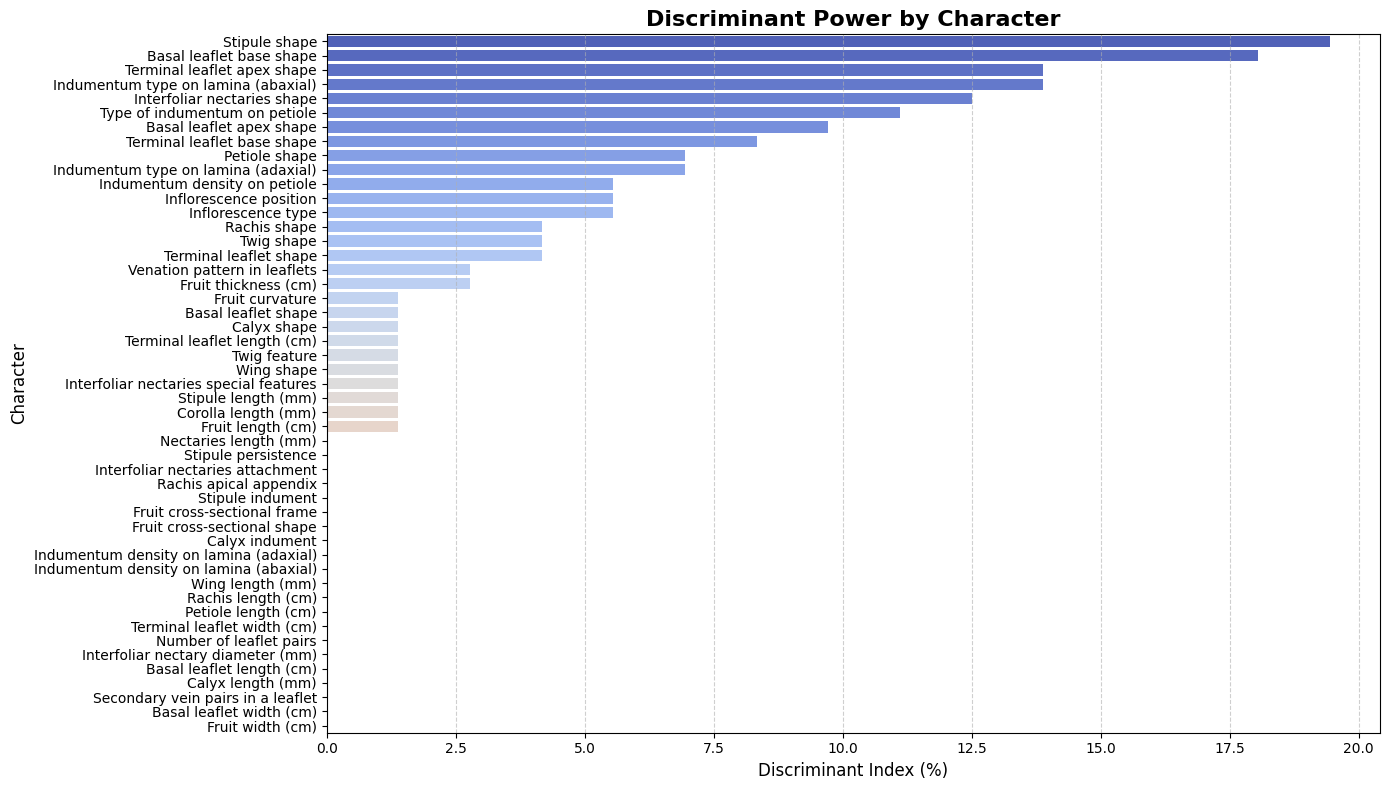

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_original = pd.read_excel("/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Inga_interactive-key_padme.xlsx", engine='openpyxl')
df['Species'] = df_original['Species']

# Check that the Species column is present
if 'Species' not in df.columns:
    raise ValueError("La columna 'Species' no está presente en el DataFrame.")

# Calculate the total number of unique species
total_species = df['Species'].nunique()

# Create dictionary to store discrimination index values
id_results = {}

# Convert results into a dataframe and sort them
for col in df.columns:
    if col != 'Species':
        unique_counts = df.groupby(col)['Species'].nunique()
        discriminated_species = unique_counts[unique_counts == 1].sum()
        id_value = (discriminated_species / total_species) * 100
        id_results[col] = id_value

id_df = pd.DataFrame.from_dict(id_results, orient='index', columns=['Discrimination Index'])
id_df = id_df.reset_index().rename(columns={'index': 'Caracter'})
id_df = id_df.sort_values(by='Discrimination Index', ascending=False)

id_df.to_excel('/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/discrimination_index.xlsx', index=False)

# show
print("Resultados del análisis del índice de discriminación:")
print(id_df)

# chart
plt.figure(figsize=(14, 8))
sns.barplot(
    x='Discrimination Index',
    y='Caracter',
    data=id_df,
    palette='coolwarm'
)

plt.xlabel("Discriminant Index (%)", fontsize=12)
plt.ylabel("Character", fontsize=12)
plt.title("Discriminant Power by Character", fontsize=16, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/LDA_paper.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print(df.columns)


Index(['Twig shape', 'Twig feature', 'Stipule shape', 'Stipule indument',
       'Stipule persistence', 'Petiole shape', 'Type of indumentum on petiole',
       'Indumentum density on petiole', 'Rachis shape',
       'Rachis apical appendix', 'Wing shape',
       'Interfoliar nectaries attachment', 'Interfoliar nectaries shape',
       'Interfoliar nectaries special features', 'Nectaries length (mm)',
       'Terminal leaflet shape', 'Terminal leaflet apex shape',
       'Terminal leaflet base shape', 'Basal leaflet shape',
       'Basal leaflet apex shape', 'Basal leaflet base shape',
       'Indumentum type on lamina (abaxial)',
       'Indumentum density on lamina (abaxial)',
       'Indumentum type on lamina (adaxial)',
       'Indumentum density on lamina (adaxial)',
       'Venation pattern in leaflets', 'Inflorescence position',
       'Inflorescence type', 'Calyx shape', 'Calyx indument',
       'Fruit curvature', 'Fruit cross-sectional shape',
       'Fruit cross-sectional fra

## **3.6 Análisis de ponderación múltiple**


This code combines three metrics—correlation (average of Spearman and Pearson), entropy, and discrimination index—into a single weighted score to rank morphological characters. It normalizes each metric, applies predefined weights (0.6 for entropy, 0.2 each for correlation and discrimination), and calculates a final score to identify the most informative and non-redundant characters for species identification.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Calculate mean absolute Spearman correlation for each character
spearman_abs = corr_spearman.abs().copy()
np.fill_diagonal(spearman_abs.values, np.nan)  # ignorar autocolumna
spearman_mean_abs = spearman_abs.mean(axis=1, skipna=True)  # redundancia media

# Create dataframe with Spearman correlation values
correlation_df = spearman_mean_abs.reset_index()
correlation_df.columns = ['Caracter', 'Spearman']

# Define correlation metric for weighting analysis
correlation_df['Correlation'] = correlation_df['Spearman']

# Merge correlation, entropy, and discrimination metrics
metrics_df = (
    correlation_df[['Caracter', 'Correlation']]     # ➜ usar 'Correlation' (no 'Spearman_Normalized')
    .merge(entropias, on='Caracter', how='inner')
    .merge(id_df[['Caracter', 'Discrimination Index']], on='Caracter', how='inner')
)

# Normalize metrics for weighted comparison
scaler = MinMaxScaler()
metrics_df[['Correlation', 'Entropy', 'Discrimination Index']] = scaler.fit_transform(
    metrics_df[['Correlation', 'Entropy', 'Discrimination Index']]
)

# Apply bilateral correlation penalty
tau_low, tau_high = 0.10, 0.60
w_low, w_high = 0.5, 1.0
c = metrics_df['Correlation']

penalty = np.where(
    c < tau_low,
    w_low * (tau_low - c) / tau_low,
    np.where(
        c > tau_high,
        w_high * (c - tau_high) / (1 - tau_high),
        0.0
    )
)

metrics_df['Correlation'] = 1 - penalty  # mayor valor = mejor (rango medio favorecido)


# Define metric weights
weights = {
    'Correlation': 0.2,
    'Entropy': 0.6,
    'Discrimination Index': 0.2
}

# Calculate final weighted score
metrics_df['Weighted Score'] = (
    metrics_df['Correlation'] * weights['Correlation'] +
    metrics_df['Entropy'] * weights['Entropy'] +
    metrics_df['Discrimination Index'] * weights['Discrimination Index']
)

# Sort score
metrics_df = metrics_df.sort_values(by='Weighted Score', ascending=False)

# Save
metrics_df.to_csv("/content/drive/MyDrive/Analisis/Inga_andes/Inga_interactive/Resultados/ponderacion_resultados.csv", index=False)
print(metrics_df)



                                  Caracter  Correlation   Entropy  \
37                           Stipule shape     1.000000  1.000000   
1                 Basal leaflet base shape     1.000000  0.916336   
45           Type of indumentum on petiole     0.882322  0.942842   
18     Indumentum type on lamina (abaxial)     0.655109  0.965403   
29                           Petiole shape     1.000000  0.945750   
38             Terminal leaflet apex shape     1.000000  0.783813   
39             Terminal leaflet base shape     1.000000  0.853855   
23             Interfoliar nectaries shape     1.000000  0.700030   
0                 Basal leaflet apex shape     1.000000  0.721931   
19     Indumentum type on lamina (adaxial)     0.479800  0.861044   
32                            Rachis shape     1.000000  0.680267   
3                      Basal leaflet shape     1.000000  0.712055   
7                              Calyx shape     0.944132  0.620391   
17           Indumentum density on

In [ ]:
# Select the 25 highest-scoring characters
top_25_caracteres = metrics_df.head(25)

# Display the 25 highest-scoring characters
print(top_25_caracteres[['Caracter', 'Weighted Score']])

# Save CSV
top_25_caracteres.to_csv("top_25_rasgos.csv", index=False)


                               Caracter  Weighted Score
37                        Stipule shape        1.000000
1              Basal leaflet base shape        0.935516
45        Type of indumentum on petiole        0.856456
18  Indumentum type on lamina (abaxial)        0.853120
29                        Petiole shape        0.838879
38          Terminal leaflet apex shape        0.813145
39          Terminal leaflet base shape        0.798027
23          Interfoliar nectaries shape        0.748590
0              Basal leaflet apex shape        0.733159
19  Indumentum type on lamina (adaxial)        0.684015
32                         Rachis shape        0.651017
3                   Basal leaflet shape        0.641519
7                           Calyx shape        0.575347
17        Indumentum density on petiole        0.540297
44                           Twig shape        0.529778
21                   Inflorescence type        0.528124
41               Terminal leaflet shape        0

# **4. Interactive key**

[https://padme.rbge.org.uk/keys/welcome/inga]